# 1. Install JAX FDM

In [ ]:
!pip install -q -U jax-fdm compas_notebook
import jax_fdm
jax_fdm.__version__

# 2. Import libraries

In [ ]:
# randomness
from random import random

# compas
from compas.colors import Color
from compas.datastructures import Network
from compas.geometry import add_vectors
from compas.geometry import Polyline
from compas.geometry import Line

# jax fdm
from jax_fdm.datastructures import FDNetwork
from jax_fdm.visualization import NotebookViewer

# 3. Define helper functions

In [ ]:
def create_polyline(length: float, num_segments: int):
    """Create the segments of a wobbly 2D arch in the XY plane.
    """
    start = [-length / 2.0, 0.0, 0.0]
    end = add_vectors(start, [length, 0.0, 0.0])
    curve = Polyline([start, end])
    points = curve.divide(num_segments)
    for point in points[1:-1]:
        point[1] = random() * 0.001
    return Polyline(points).lines


def plot_arch(arch, *args, **kwargs):
    """Display a funky arch in a notebook viewer, looking straight at the XY plane.
    """
    viewer = NotebookViewer(viewport="top")
    viewer.add(arch, show_nodes=True, edgewidth=(0.02, 0.06), nodesize=0.15, loadscale=0.5, *args, **kwargs)
    viewer.show()
    return viewer


def connect_arches(arch_1, arch_2):
    """Connect the nodes of two arches with a line.
    """
    lines = []
    for na, nb in zip(arch_1.nodes(), arch_2.nodes()):
        line = Line(arch_1.node_coordinates(na), arch_2.node_coordinates(nb))
        lines.append(line)
    return lines


def arch_height(arch):
    """Compute the maximum y coordinate of the nodes of the arch.
    """
    return max(arch.nodes_attribute(name="y"))


def plot_connected_arches(arch_1, arch_2):
    """Plot two arches whose nodes are pairwise connected by a line.
    The second arch is drawn as a plain network (no forces or reactions shown).
    The viewer is returned without showing it, so more geometry can be added.
    """
    viewer = NotebookViewer(viewport="top")
    viewer.add(arch_1, show_nodes=True, edgewidth=(0.02, 0.06), nodesize=0.15, loadscale=0.5)
    viewer.add(arch_2.copy(cls=Network), show_points=False)
    for line in connect_arches(arch_1, arch_2):
        viewer.add(line)
    return viewer


def plot_horizontal_line(height, viewer):
    """Add a horizontal line at a given height and display the viewer.
    """
    line_horizontal = Line([0.0, height, 0.0], [1.0, height, 0.0])
    viewer.add(line_horizontal, linecolor=Color.orange())
    viewer.show()
    return viewer

# 4. Model an arch 

In [ ]:
# Create an arch modeled as a JAX FDM network
polyline = create_polyline(length=5.0, num_segments=10)
arch = FDNetwork.from_lines(polyline)
plot_arch(arch)

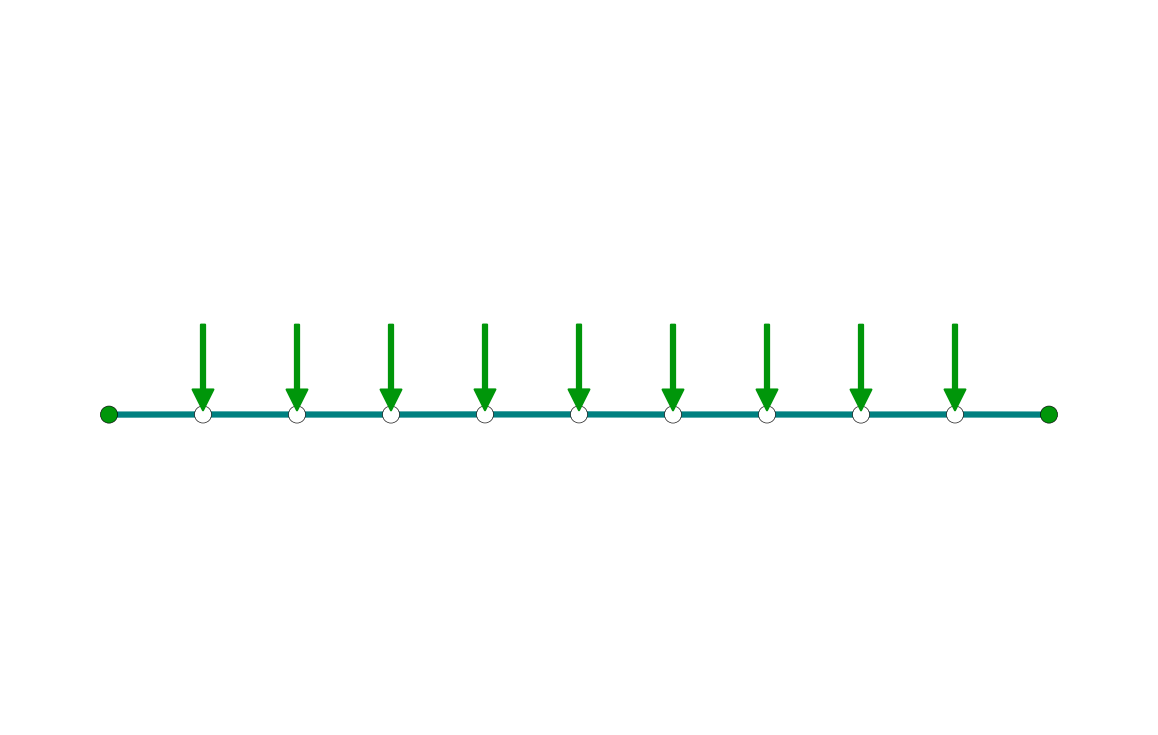

In [5]:
# Assign supports to the arch
arch.node_support(0)
arch.node_support(10)

# Apply loads at the nodes
for node in arch.nodes_free():
    arch.node_load(node, [0.0, -0.5, 0.0])

# Set edge force densities
for edge in arch.edges():
    arch.edge_forcedensity(edge, -3.0)

# display arch
plot_arch(arch)

# 5. Form-find the arch

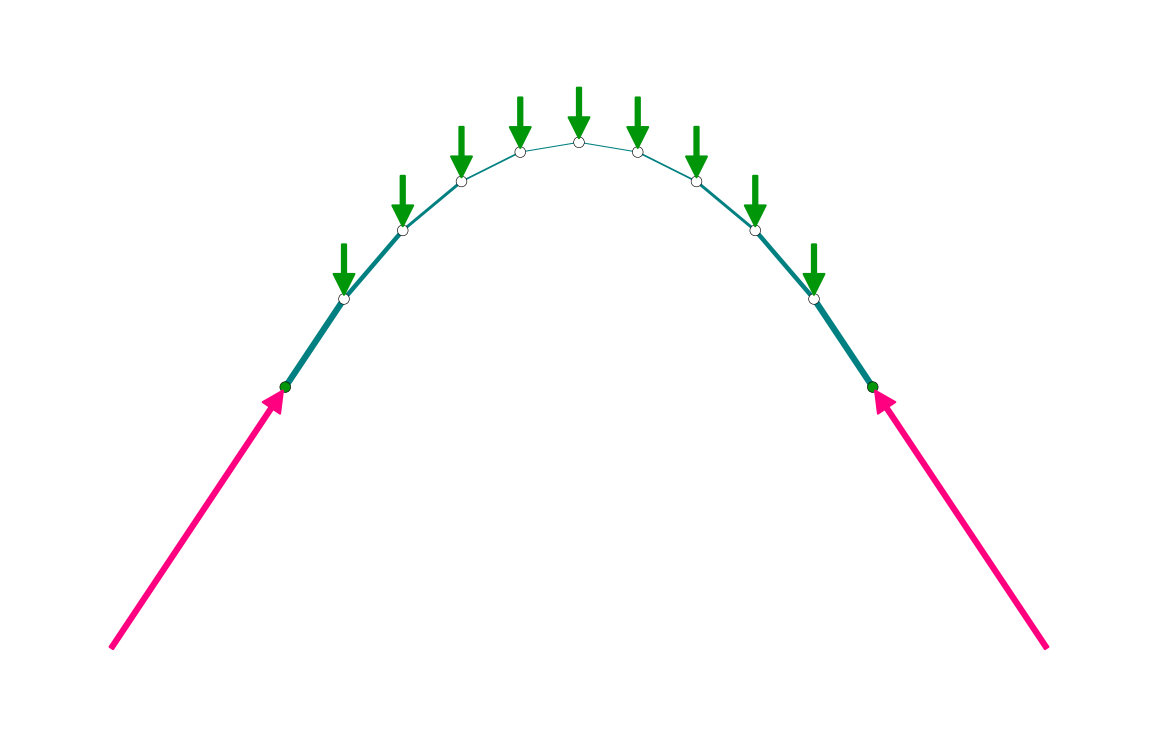

In [6]:
from jax_fdm.equilibrium import fdm

# form-find the arch using the force density method (fdm)
arch_eq = fdm(arch)

# display arch
plot_arch(arch_eq)

In [ ]:
arch.edges_forcedensities(-2.0)
arch_eq = fdm(arch)
viewer = plot_connected_arches(arch_eq, arch)
plot_horizontal_line(1.0, viewer)

# 6. Constrained form-finding (Unconstrained optimization)

In [8]:
from jax_fdm.equilibrium import constrained_fdm

from jax_fdm.goals import NodeYCoordinateGoal

from jax_fdm.parameters import EdgeForceDensityParameter

from jax_fdm.losses import Loss
from jax_fdm.losses import SquaredError

from jax_fdm.optimization import SLSQP

In [ ]:
plot_arch(arch)

In [ ]:
# formulate goals
goals = []
goal = NodeYCoordinateGoal(key=5, target=1.0)  # target height
goals.append(goal)

# set optimizable parameters
parameters = []
for edge in arch.edges():
    parameter = EdgeForceDensityParameter(edge, bound_low=None, bound_up=0.0)
    parameters.append(parameter)

# define loss (objective) function
error = SquaredError(goals)
loss = Loss(error)

# instantiate the optimizer
optimizer = SLSQP()

# solve constrained form finding problem
arch_c = constrained_fdm(arch, optimizer, loss, parameters)

# plot arch
viewer = plot_connected_arches(arch_c, arch)
plot_horizontal_line(1.0, viewer)

In [11]:
arch_height(arch_c)

1.0002747621755288

# 7. Constrained form-finding (Constrained optimization)

In [ ]:
from jax_fdm.constraints import NodeXCoordinateConstraint

# add horizontal projection constraints
constraints = []
for node in arch.nodes_free():
    x, y, z = arch.node_coordinates(node)
    constraint = NodeXCoordinateConstraint(node, bound_low=x-1e-6, bound_up=x+1e-6)
    constraints.append(constraint)

# solve constrained form finding problem
arch_c2 = constrained_fdm(arch, optimizer, loss, parameters, constraints)

# plot arch
viewer = plot_connected_arches(arch_c2, arch)
plot_horizontal_line(1.0, viewer)

# print out arch height
print(arch_height(arch_c2))

In [ ]:
# Visualize the form-found arch in 3D
viewer = NotebookViewer()
viewer.add(arch_eq)
viewer.show()